In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:

df = pd.read_csv("..\\data\\raw\\desafio_nps_fase_1.csv")
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


In [4]:

print("Quantidade de linhas e colunas:")
print(df.shape)

print("\nColunas da base:")
print(df.columns.tolist())

print("\nTipos de dados:")
display(df.dtypes)

print("\nPrimeiras linhas:")
display(df.head())

Quantidade de linhas e colunas:
(2500, 19)

Colunas da base:
['customer_id', 'customer_age', 'customer_region', 'customer_tenure_months', 'order_id', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'nps_score', 'repeat_purchase_30d', 'complaints_count', 'csat_internal_score']

Tipos de dados:


customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object


Primeiras linhas:


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.90,0,3,6.50
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.40,0,3,0.00
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.80,0,7,1.50
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.90,0,4,0.30
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.10,0,3,7.90


In [5]:

print("Valores nulos por coluna:")
display(df.isna().sum())

print("\nDuplicidades em customer_id:")
print(df["customer_id"].duplicated().sum())

print("\nDuplicidades em order_id:")
print(df["order_id"].duplicated().sum())

Valores nulos por coluna:


customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64


Duplicidades em customer_id:
0

Duplicidades em order_id:
0


In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.00,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.00,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.00,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.00,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.00,434.26,289.77,7.76,220.25,375.51,577.29,1983.81
items_quantity,2500.00,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.00,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.00,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.00,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.00,2.19,1.45,0.00,1.00,2.00,3.00,8.00


In [7]:

def classificar_nps(score):
    
    """
    Classifica o NPS em categorias: Detrator, Neutro ou Promotor com base na pontuação fornecida.
    Args:
        score (float): A pontuação do NPS (0 a 10).
    Returns:
        str: A categoria correspondente ao NPS.
    """
    if score < 7:
        return "Detrator"
    elif score < 9:
        return "Neutro"
    else:
        return "Promotor"

df["nps_category"] = df["nps_score"].apply(classificar_nps)

display(df[["nps_score", "nps_category"]].head(10))

,nps_score,nps_category
0,6.90,Detrator
1,2.40,Detrator
2,4.80,Detrator
3,5.90,Detrator
4,6.10,Detrator
5,0.90,Detrator
6,1.40,Detrator
7,0.00,Detrator
8,6.20,Detrator
9,2.70,Detrator


In [8]:

nps_medio = df["nps_score"].mean()
nps_mediana = df["nps_score"].median()

distribuicao_nps = (
    df["nps_category"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

distribuicao_nps.columns = ["categoria", "percentual"]

percentual_promotores = (df["nps_category"] == "Promotor").mean() * 100
percentual_detratores = (df["nps_category"] == "Detrator").mean() * 100
indice_nps = percentual_promotores - percentual_detratores

recompra_30d = df["repeat_purchase_30d"].mean() * 100

print(f"NPS médio: {nps_medio:.2f}")
print(f"Mediana do NPS: {nps_mediana:.2f}")
print(f"% Promotores: {percentual_promotores:.2f}%")
print(f"% Detratores: {percentual_detratores:.2f}%")
print(f"Índice NPS estimado: {indice_nps:.2f}")
print(f"Taxa de recompra em 30 dias: {recompra_30d:.2f}%")

display(distribuicao_nps)

NPS médio: 4.38
Mediana do NPS: 4.40
% Promotores: 4.40%
% Detratores: 84.36%
Índice NPS estimado: -79.96
Taxa de recompra em 30 dias: 8.72%


,categoria,percentual
0,Detrator,84.36
1,Neutro,11.24
2,Promotor,4.40


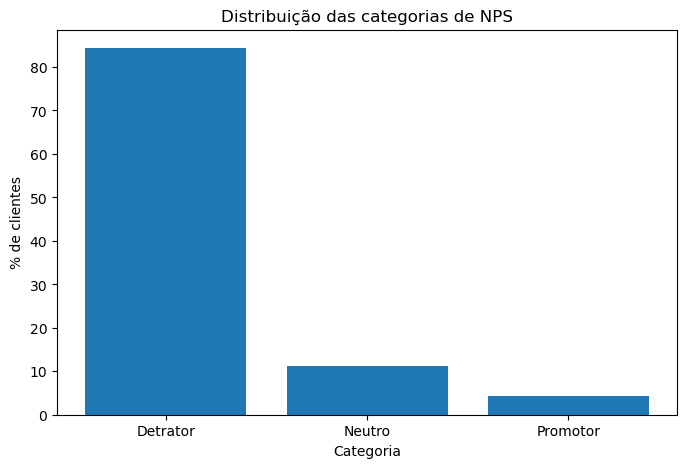

In [9]:

ordem_nps = ["Detrator", "Neutro", "Promotor"]

plot_data = (
    df["nps_category"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(ordem_nps)
)

plt.figure(figsize=(8, 5))
plt.bar(plot_data.index, plot_data.values)
plt.title("Distribuição das categorias de NPS")
plt.ylabel("% de clientes")
plt.xlabel("Categoria")
plt.show()

## Leitura de negócio

### A primeira pergunta é: **A empresa tem mais clientes satisfeitos ou insatisfeitos?**

Para responder, olhamos:
1. Média do NPS;
2. Percentual de detratores;
3. Percentual de promotores;
4. Índice NPS estimado.

Se a base tiver muitos detratores e poucos promotores, o problema não é pontual.
Ele indica uma falha recorrente na experiência do cliente.

In [10]:

colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()

correlacoes = (
    df[colunas_numericas]
    .corr()["nps_score"]
    .drop("nps_score")
    .sort_values(key=lambda x: abs(x), ascending=False)
    .reset_index()
)

correlacoes.columns = ["variavel", "correlacao_com_nps"]

display(correlacoes)

,variavel,correlacao_com_nps
0,delivery_delay_days,-0.60
1,repeat_purchase_30d,0.57
2,csat_internal_score,0.56
3,complaints_count,-0.50
4,customer_service_contacts,-0.35
5,resolution_time_days,-0.19
6,freight_value,-0.04
7,order_value,0.04
8,delivery_attempts,0.03
9,discount_value,0.03


In [11]:

def interpretar_correlacao(valor):
    """Interpreta a correlação com base no valor fornecido.
    Args:
        valor (float): O valor da correlação.
    Returns:
        str: Uma descrição da correlação em termos de direção e intensidade.
    """
    direcao = "positiva" if valor > 0 else "negativa"

    intensidade_abs = abs(valor)

    if intensidade_abs >= 0.50:
        intensidade = "forte"
    elif intensidade_abs >= 0.30:
        intensidade = "moderada"
    elif intensidade_abs >= 0.10:
        intensidade = "fraca"
    else:
        intensidade = "muito fraca"

    return f"Correlação {direcao} {intensidade}"

correlacoes["interpretacao"] = correlacoes["correlacao_com_nps"].apply(interpretar_correlacao)

display(correlacoes)

,variavel,correlacao_com_nps,interpretacao
0,delivery_delay_days,-0.60,Correlação negativa forte
1,repeat_purchase_30d,0.57,Correlação positiva forte
2,csat_internal_score,0.56,Correlação positiva forte
3,complaints_count,-0.50,Correlação negativa moderada
4,customer_service_contacts,-0.35,Correlação negativa moderada
5,resolution_time_days,-0.19,Correlação negativa fraca
6,freight_value,-0.04,Correlação negativa muito fraca
7,order_value,0.04,Correlação positiva muito fraca
8,delivery_attempts,0.03,Correlação positiva muito fraca
9,discount_value,0.03,Correlação positiva muito fraca


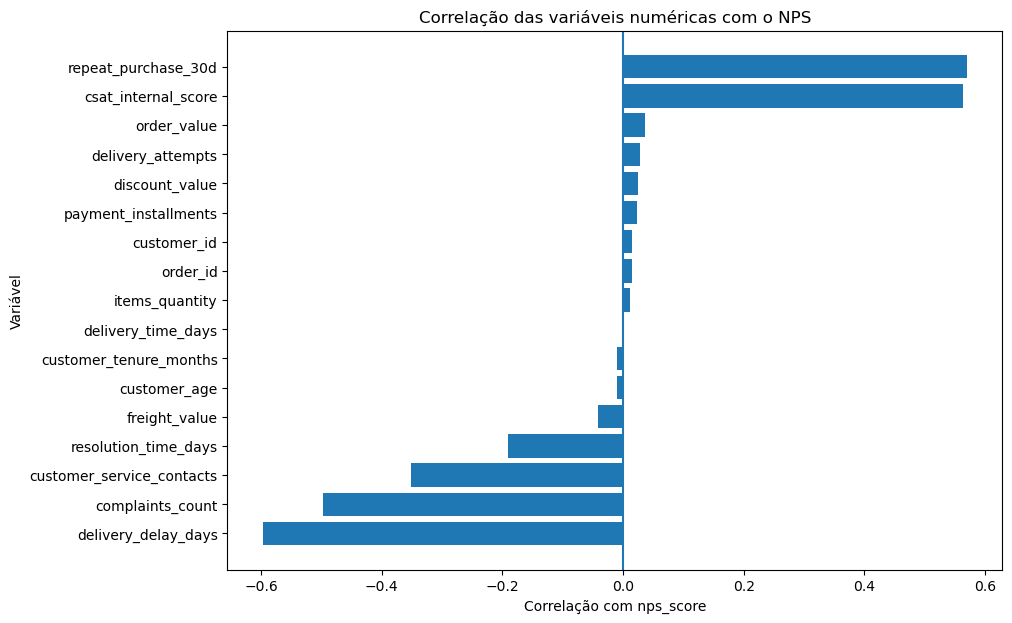

In [12]:

top_corr = correlacoes.copy()
top_corr = top_corr.sort_values("correlacao_com_nps")

plt.figure(figsize=(10, 7))
plt.barh(top_corr["variavel"], top_corr["correlacao_com_nps"])
plt.title("Correlação das variáveis numéricas com o NPS")
plt.xlabel("Correlação com nps_score")
plt.ylabel("Variável")
plt.axvline(0)
plt.show()

### Correlações:

Correlação negativa:
Quando a variável aumenta, o NPS tende a cair.
Exemplo esperado: mais atraso, mais reclamações ou mais contatos com atendimento.

Correlação positiva:
Quando a variável aumenta, o NPS tende a subir.
Exemplo esperado: maior CSAT interno ou recompra.

A correlação não prova causa, mas ajuda a priorizar investigações.
Por isso, depois da correlação, vamos abrir cada variável crítica em grupos.

In [13]:

def resumo_nps_por_grupo(df, coluna_grupo, ordem=None):
    """
    Resume o NPS por grupo.
    Args:
        df (pd.DataFrame): O DataFrame com os dados.
        coluna_grupo (str): O nome da coluna pelo qual agrupar.
        ordem (list, optional): A ordem dos grupos.
    Returns:
        pd.DataFrame: O DataFrame com o resumo do NPS por grupo.
    """
    resumo = (
        df
        .groupby(coluna_grupo)
        .agg(
            pedidos=("order_id", "count"),
            nps_medio=("nps_score", "mean"),
            percentual_detratores=("nps_category", lambda x: (x == "Detrator").mean() * 100),
            percentual_neutros=("nps_category", lambda x: (x == "Neutro").mean() * 100),
            percentual_promotores=("nps_category", lambda x: (x == "Promotor").mean() * 100),
            recompra_30d=("repeat_purchase_30d", lambda x: x.mean() * 100)
        )
        .reset_index()
    )

    if ordem is not None:
        resumo[coluna_grupo] = pd.Categorical(resumo[coluna_grupo], categories=ordem, ordered=True)
        resumo = resumo.sort_values(coluna_grupo)

    return resumo

In [14]:

def agrupar_atraso(dias):
    """
    Agrupa os dias de atraso em faixas.
    Args:
        dias (int): O número de dias de atraso.
    Returns:
        str: A faixa de atraso correspondente.
    """
    if dias == 0:
        return "0 dias"
    elif dias == 1:
        return "1 dia"
    elif dias == 2:
        return "2 dias"
    elif dias == 3:
        return "3 dias"
    else:
        return "4+ dias"

df["faixa_atraso"] = df["delivery_delay_days"].apply(agrupar_atraso)

ordem_atraso = ["0 dias", "1 dia", "2 dias", "3 dias", "4+ dias"]

resumo_atraso = resumo_nps_por_grupo(df, "faixa_atraso", ordem_atraso)

display(resumo_atraso)

,faixa_atraso,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
0,0 dias,277,6.86,51.62,30.32,18.05,33.94
1,1 dia,615,5.55,73.98,18.86,7.15,14.80
2,2 dias,646,4.58,87.93,10.06,2.01,4.02
3,3 dias,525,3.44,96.76,2.67,0.57,1.14
4,4+ dias,437,2.00,99.54,0.46,0.00,0.23


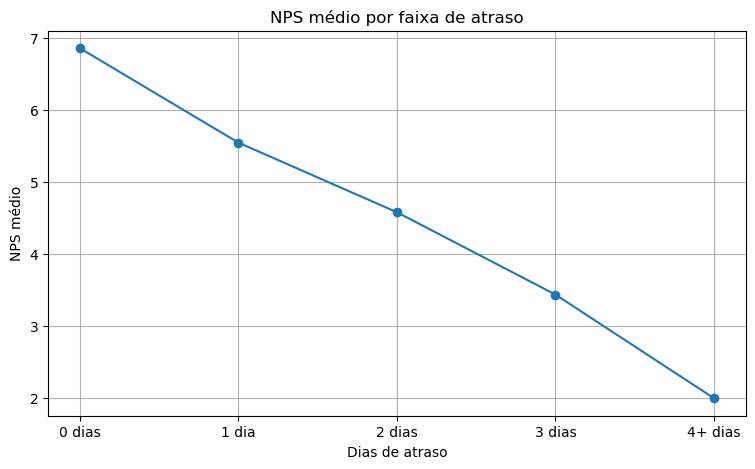

In [15]:

plt.figure(figsize=(9, 5))
plt.plot(resumo_atraso["faixa_atraso"], resumo_atraso["nps_medio"], marker="o")
plt.title("NPS médio por faixa de atraso")
plt.xlabel("Dias de atraso")
plt.ylabel("NPS médio")
plt.grid(True)
plt.show()

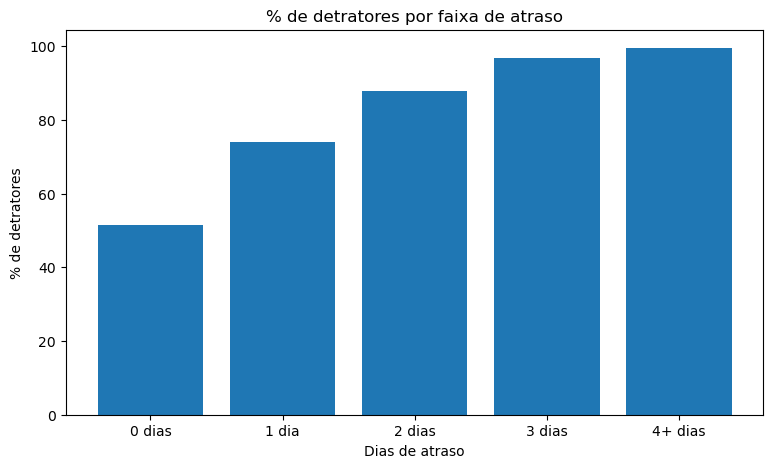

In [16]:

plt.figure(figsize=(9, 5))
plt.bar(resumo_atraso["faixa_atraso"], resumo_atraso["percentual_detratores"])
plt.title("% de detratores por faixa de atraso")
plt.xlabel("Dias de atraso")
plt.ylabel("% de detratores")
plt.show()

### Raciocínio:

A correlação entre delivery_delay_days e nps_score indica que atraso é um fator crítico.
Agora, ao agrupar por dias de atraso, conseguimos enxergar o ponto de ruptura.

Pergunta de negócio:
**A partir de quantos dias de atraso o cliente começa a virar detrator?**

Se o NPS cai fortemente a partir de 2 ou 3 dias de atraso, a empresa deve criar alertas antes desse limite.

In [17]:

def agrupar_reclamacoes(qtd):
    """
    Agrupa o número de reclamações em faixas.
    Args:
        qtd (int): O número de reclamações.
    Returns:
        str: A faixa de reclamações correspondente.
    """
    if qtd == 0:
        return "0 reclamações"
    elif qtd == 1:
        return "1 reclamação"
    elif qtd == 2:
        return "2 reclamações"
    elif qtd == 3:
        return "3 reclamações"
    elif qtd <= 5:
        return "4-5 reclamações"
    else:
        return "6+ reclamações"

df["faixa_reclamacoes"] = df["complaints_count"].apply(agrupar_reclamacoes)

ordem_reclamacoes = [
    "0 reclamações",
    "1 reclamação",
    "2 reclamações",
    "3 reclamações",
    "4-5 reclamações",
    "6+ reclamações"
]

resumo_reclamacoes = resumo_nps_por_grupo(df, "faixa_reclamacoes", ordem_reclamacoes)

display(resumo_reclamacoes)

,faixa_reclamacoes,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
0,0 reclamações,23,8.52,17.39,43.48,39.13,69.57
1,1 reclamação,122,7.77,30.33,48.36,21.31,42.62
2,2 reclamações,277,6.05,65.34,23.47,11.19,19.49
3,3 reclamações,507,4.91,81.66,13.81,4.54,8.88
4,4-5 reclamações,1044,3.98,91.86,6.23,1.92,4.31
5,6+ reclamações,527,2.82,97.53,2.28,0.19,1.14


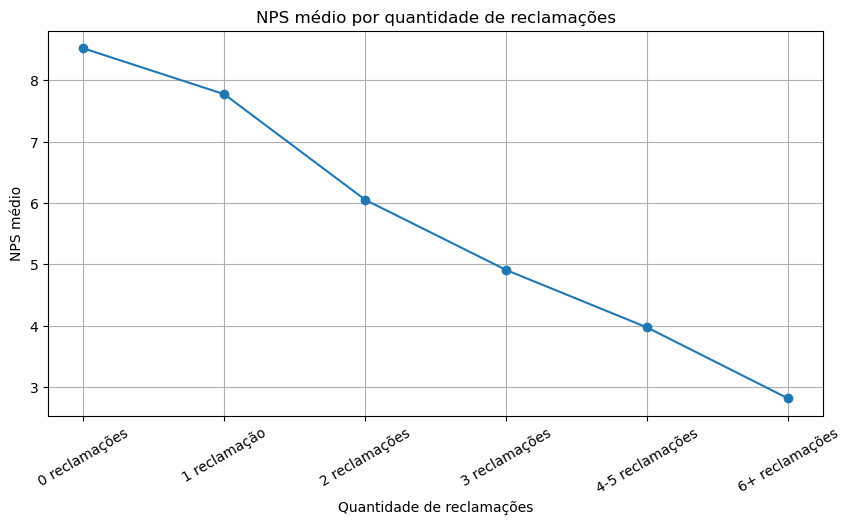

In [18]:

plt.figure(figsize=(10, 5))
plt.plot(resumo_reclamacoes["faixa_reclamacoes"], resumo_reclamacoes["nps_medio"], marker="o")
plt.title("NPS médio por quantidade de reclamações")
plt.xlabel("Quantidade de reclamações")
plt.ylabel("NPS médio")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

### Raciocínio:

A variável complaints_count tem correlação negativa com NPS.
Isso significa que, quanto mais reclamações, menor tende a ser a satisfação.

Mas o agrupamento mostra algo mais útil para o negócio:
em qual volume de reclamações o NPS despenca?

Se a queda forte começa a partir de 2 reclamações, por exemplo,
esse é um sinal para priorização no atendimento.

In [19]:

def agrupar_contatos(qtd):
    """
    Agrupa o número de contatos em faixas.
    Args:
        qtd (int): O número de contatos.
    Returns:
        str: A faixa de contatos correspondente.
    """
    if qtd == 0:
        return "0 contatos"
    elif qtd == 1:
        return "1 contato"
    elif qtd == 2:
        return "2 contatos"
    else:
        return "3+ contatos"

df["faixa_contatos"] = df["customer_service_contacts"].apply(agrupar_contatos)

ordem_contatos = ["0 contatos", "1 contato", "2 contatos", "3+ contatos"]

resumo_contatos = resumo_nps_por_grupo(df, "faixa_contatos", ordem_contatos)

display(resumo_contatos)

,faixa_contatos,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
0,0 contatos,554,5.54,70.76,18.95,10.29,17.87
1,1 contato,816,4.66,83.95,11.64,4.41,9.19
2,2 contatos,640,4.12,88.59,9.22,2.19,5.31
3,3+ contatos,490,2.94,94.90,4.49,0.61,2.04


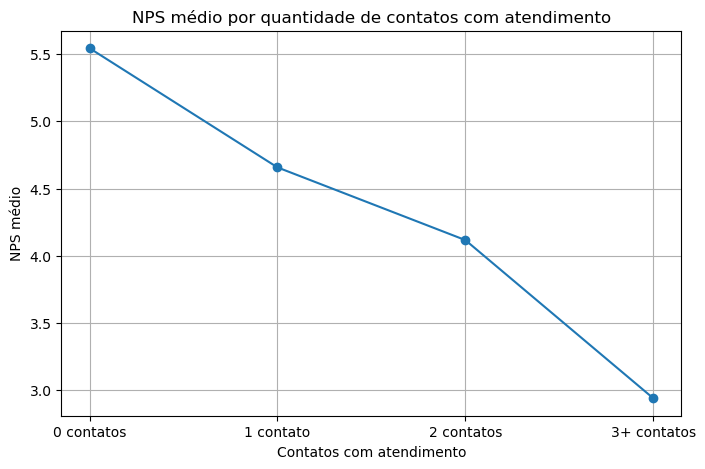

In [20]:

plt.figure(figsize=(8, 5))
plt.plot(resumo_contatos["faixa_contatos"], resumo_contatos["nps_medio"], marker="o")
plt.title("NPS médio por quantidade de contatos com atendimento")
plt.xlabel("Contatos com atendimento")
plt.ylabel("NPS médio")
plt.grid(True)
plt.show()

### Raciocínio:

Muitos contatos com atendimento indicam esforço do cliente.
Mesmo que o atendimento resolva o problema, o cliente já precisou gastar tempo e energia.

Por isso, customer_service_contacts tende a ser um bom indicador de atrito na jornada.
Se clientes com 3 ou mais contatos têm NPS muito baixo, eles devem entrar em uma fila prioritária.

In [21]:

def agrupar_resolucao(dias):
    """
    Agrupa os dias de resolução em faixas.
    Args:
        dias (int): O número de dias de resolução.
    Returns:
        str: A faixa de resolução correspondente.
    """
    if dias <= 2:
        return "0-2 dias"
    elif dias <= 5:
        return "3-5 dias"
    elif dias <= 7:
        return "6-7 dias"
    else:
        return "8+ dias"

df["faixa_resolucao"] = df["resolution_time_days"].apply(agrupar_resolucao)

ordem_resolucao = ["0-2 dias", "3-5 dias", "6-7 dias", "8+ dias"]

resumo_resolucao = resumo_nps_por_grupo(df, "faixa_resolucao", ordem_resolucao)

display(resumo_resolucao)

,faixa_resolucao,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
0,0-2 dias,629,5.04,77.74,14.79,7.47,12.88
1,3-5 dias,619,4.51,82.55,12.28,5.17,10.18
2,6-7 dias,410,4.29,85.61,11.22,3.17,8.54
3,8+ dias,842,3.83,90.02,7.84,2.14,4.63


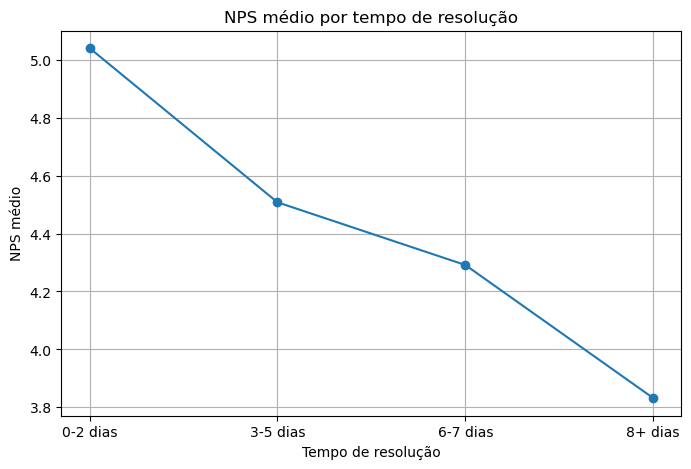

In [22]:

plt.figure(figsize=(8, 5))
plt.plot(resumo_resolucao["faixa_resolucao"], resumo_resolucao["nps_medio"], marker="o")
plt.title("NPS médio por tempo de resolução")
plt.xlabel("Tempo de resolução")
plt.ylabel("NPS médio")
plt.grid(True)
plt.show()

### Raciocínio:

Tempo de resolução tem correlação negativa com NPS, mas menor do que atraso e reclamações.

Isso indica que o tempo de resolução importa,
mas talvez ele seja consequência de problemas anteriores:
atraso, reclamação e múltiplos contatos.

Mesmo assim, reduzir o tempo de resolução pode impedir que clientes em risco virem detratores.

In [23]:

def agrupar_csat(score):
    """
    Agrupa o score de CSAT em faixas.
    Args:
        score (int): O score de CSAT.
    Returns:
        str: A faixa de CSAT correspondente.
    """
    if score <= 3:
        return "CSAT baixo"
    elif score <= 6:
        return "CSAT médio"
    elif score <= 8:
        return "CSAT alto"
    else:
        return "CSAT muito alto"

df["faixa_csat"] = df["csat_internal_score"].apply(agrupar_csat)

ordem_csat = ["CSAT baixo", "CSAT médio", "CSAT alto", "CSAT muito alto"]

resumo_csat = resumo_nps_por_grupo(df, "faixa_csat", ordem_csat)

display(resumo_csat)

,faixa_csat,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
1,CSAT baixo,1361,3.36,94.05,5.00,0.96,2.50
3,CSAT médio,835,5.10,81.68,14.37,3.95,9.10
0,CSAT alto,261,6.74,52.87,31.03,16.09,31.03
2,CSAT muito alto,43,8.34,20.93,27.91,51.16,62.79


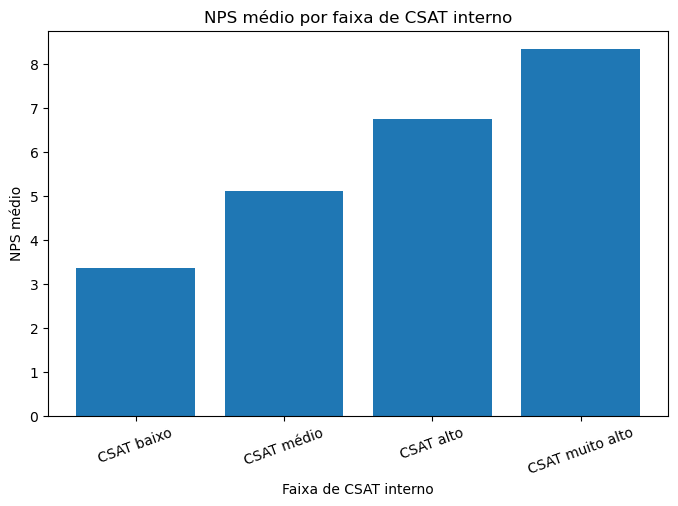

In [24]:

plt.figure(figsize=(8, 5))
plt.bar(resumo_csat["faixa_csat"], resumo_csat["nps_medio"])
plt.title("NPS médio por faixa de CSAT interno")
plt.xlabel("Faixa de CSAT interno")
plt.ylabel("NPS médio")
plt.xticks(rotation=20)
plt.show()

### Raciocínio:

csat_internal_score tem correlação positiva com NPS.
Isso é esperado, porque ambos medem satisfação.

Mas existe um cuidado:
se o CSAT for medido depois da experiência completa,
ele pode não ser adequado para prever NPS antecipadamente.

Para modelo preditivo, precisamos confirmar o momento em que o CSAT é gerado

In [25]:

resumo_recompra = resumo_nps_por_grupo(df, "repeat_purchase_30d")

resumo_recompra["repeat_purchase_30d"] = resumo_recompra["repeat_purchase_30d"].map({
    0: "Não recomprou",
    1: "Recomprou"
})

display(resumo_recompra)

,repeat_purchase_30d,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
0,Não recomprou,2282,3.94,92.42,7.58,0.00,0.00
1,Recomprou,218,9.01,0.00,49.54,50.46,100.00


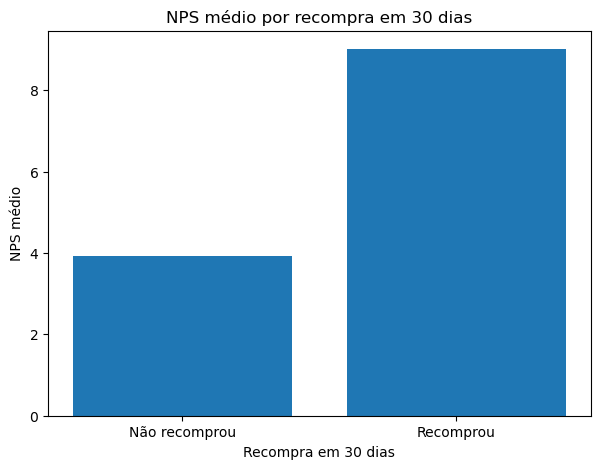

In [26]:

plt.figure(figsize=(7, 5))
plt.bar(resumo_recompra["repeat_purchase_30d"], resumo_recompra["nps_medio"])
plt.title("NPS médio por recompra em 30 dias")
plt.xlabel("Recompra em 30 dias")
plt.ylabel("NPS médio")
plt.show()

### Raciocínio:

repeat_purchase_30d tem correlação positiva forte com NPS.
Clientes que recompram tendem a estar mais satisfeitos.

Mas existe um cuidado importante:
essa variável ocorre depois do pedido e possivelmente depois da pesquisa de NPS.

Então ela é útil para análise de negócio,
mas pode gerar vazamento de dados em um modelo que tenta prever NPS antes da pesquisa.

In [27]:

resumo_regiao = resumo_nps_por_grupo(df, "customer_region")
resumo_regiao = resumo_regiao.sort_values("nps_medio")

display(resumo_regiao)

,customer_region,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
0,Centro-Oeste,468,4.21,84.19,10.47,5.34,8.33
3,Sudeste,520,4.37,83.65,11.92,4.42,8.85
2,Norte,506,4.38,85.18,11.26,3.56,7.91
1,Nordeste,485,4.42,85.57,10.10,4.33,7.63
4,Sul,521,4.49,83.30,12.28,4.41,10.75


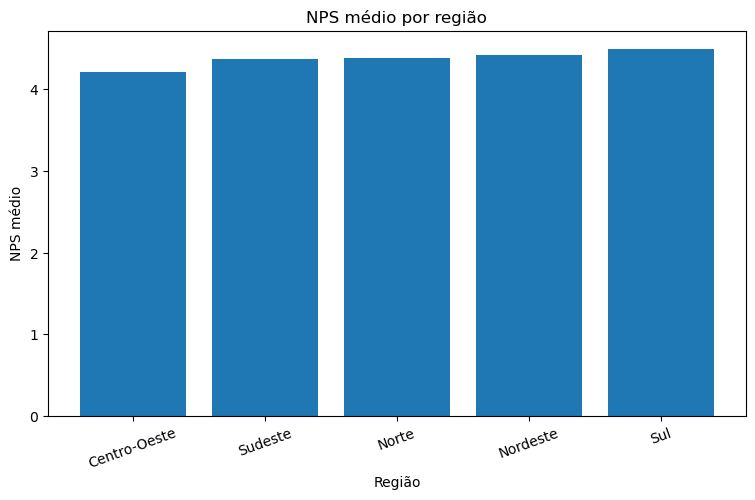

In [28]:

plt.figure(figsize=(9, 5))
plt.bar(resumo_regiao["customer_region"], resumo_regiao["nps_medio"])
plt.title("NPS médio por região")
plt.xlabel("Região")
plt.ylabel("NPS médio")
plt.xticks(rotation=20)
plt.show()

### Raciocínio:

A região ajuda a verificar se o problema é localizado.
Se todas as regiões têm NPS parecido, o problema provavelmente não é regional.

Nesse caso, faz mais sentido priorizar fatores operacionais,
como atraso, reclamações e atendimento.

In [29]:
df['faixa_etaria'] = pd.cut(
    df['customer_age'], 
    bins=[0, 25, 35, 45, 60, 100], 
    labels=['Até 25 anos', '26 a 35 anos', '36 a 45 anos', '46 a 60 anos', 'Mais de 60']
)

resumo_faixa_etaria = resumo_nps_por_grupo(df, "faixa_etaria")
resumo_faixa_etaria = resumo_faixa_etaria.sort_values("faixa_etaria")

display(resumo_faixa_etaria)

,faixa_etaria,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
0,Até 25 anos,389,4.48,84.83,10.54,4.63,9.00
1,26 a 35 anos,465,4.56,80.43,13.98,5.59,9.89
2,36 a 45 anos,517,4.12,88.59,8.32,3.09,6.58
3,46 a 60 anos,714,4.29,85.01,11.20,3.78,7.98
4,Mais de 60,415,4.56,81.93,12.53,5.54,11.08


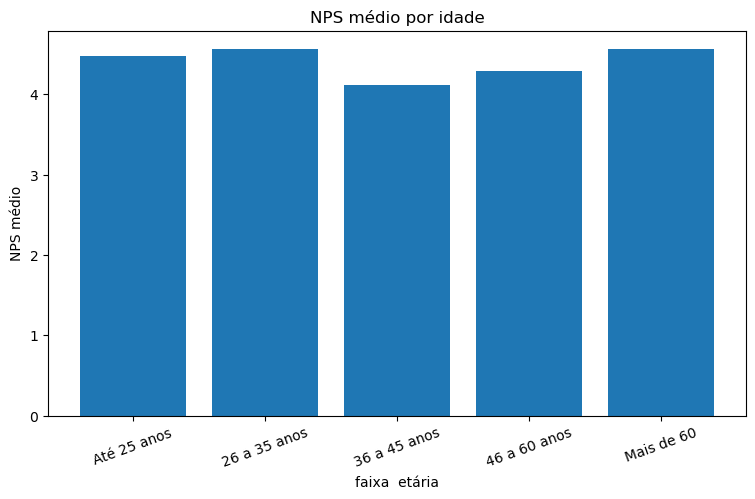

In [30]:
plt.figure(figsize=(9, 5))
plt.bar(resumo_faixa_etaria["faixa_etaria"], resumo_faixa_etaria["nps_medio"])
plt.title("NPS médio por idade")
plt.xlabel("faixa  etária")
plt.ylabel("NPS médio")
plt.xticks(rotation=20)
plt.show()

### Raciocínio:

A idade ajuda a entender se temos algum perfil de cliente mais propenso a ser um detrator.
Se todas as faixas etárias apresentarem comportamentos similares, isso significa que não há um perfil demográfico específico para a insatisfação.  
  
Reforçando ainda mais a necessidade de priorizarmos os fatores operacionais."

In [31]:

variaveis_pedido = [
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "freight_value"
]

correlacoes_pedido = correlacoes[correlacoes["variavel"].isin(variaveis_pedido)]

display(correlacoes_pedido)

,variavel,correlacao_com_nps,interpretacao
6,freight_value,-0.04,Correlação negativa muito fraca
7,order_value,0.04,Correlação positiva muito fraca
9,discount_value,0.03,Correlação positiva muito fraca
10,payment_installments,0.02,Correlação positiva muito fraca
13,items_quantity,0.01,Correlação positiva muito fraca


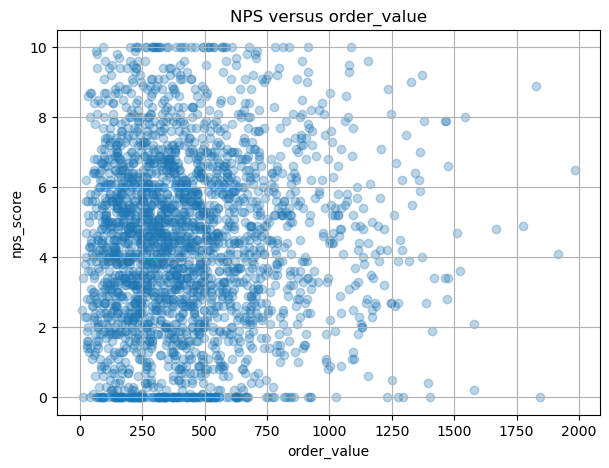

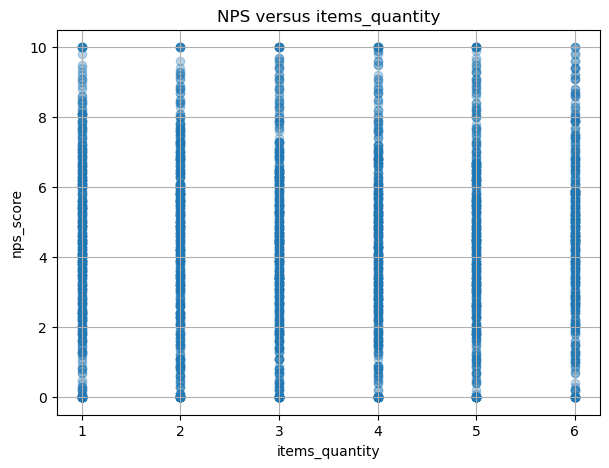

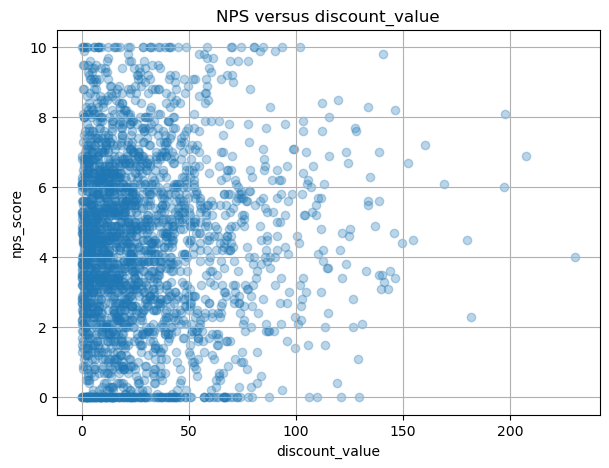

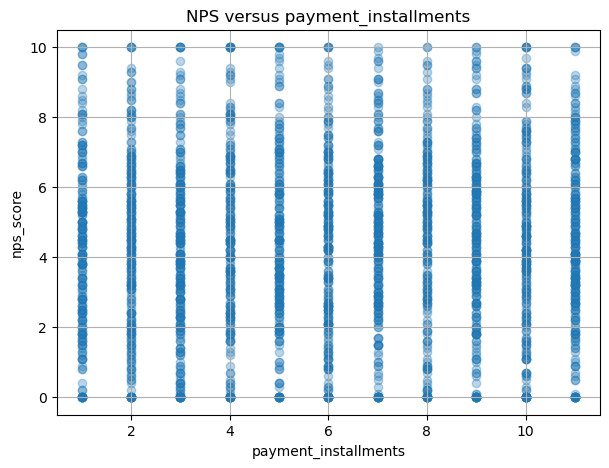

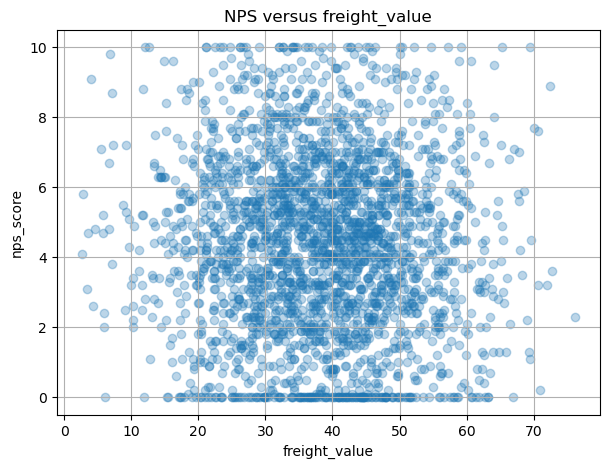

In [32]:

for coluna in variaveis_pedido:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[coluna], df["nps_score"], alpha=0.3)
    plt.title(f"NPS versus {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("nps_score")
    plt.grid(True)
    plt.show()

### Raciocínio:

As variáveis de pedido ajudam a responder:
o cliente fica mais insatisfeito por causa de valor, frete, desconto ou parcelamento?

Se essas correlações forem fracas,
a leitura é que o NPS baixo não está sendo explicado principalmente por preço ou composição do pedido.

O foco do plano de ação deve estar mais na operação:
entrega, reclamações e atendimento.

In [33]:
# Classificação de clientes/pedidos de alto risco com base em atraso na entrega e número de reclamações

alto_risco = df[
    (df["delivery_delay_days"] >= 3) &
    (df["complaints_count"] >= 4)
].copy()

print("Quantidade de clientes/pedidos no grupo de alto risco:")
print(len(alto_risco))

print("\nNPS médio do grupo de alto risco:")
print(round(alto_risco["nps_score"].mean(), 2))

print("\n% de detratores no grupo de alto risco:")
print(round((alto_risco["nps_category"] == "Detrator").mean() * 100, 2))

print("\nTaxa de recompra em 30 dias no grupo de alto risco:")
print(round(alto_risco["repeat_purchase_30d"].mean() * 100, 2))

Quantidade de clientes/pedidos no grupo de alto risco:
670

NPS médio do grupo de alto risco:
2.36

% de detratores no grupo de alto risco:
99.7

Taxa de recompra em 30 dias no grupo de alto risco:
0.3


In [34]:

df["grupo_risco"] = np.where(
    (df["delivery_delay_days"] >= 3) & (df["complaints_count"] >= 4),
    "Alto risco",
    "Demais clientes"
)

resumo_risco = resumo_nps_por_grupo(df, "grupo_risco")

display(resumo_risco)

,grupo_risco,pedidos,nps_medio,percentual_detratores,percentual_neutros,percentual_promotores,recompra_30d
0,Alto risco,670,2.36,99.70,0.00,0.30,0.30
1,Demais clientes,1830,5.12,78.74,15.36,5.90,11.80


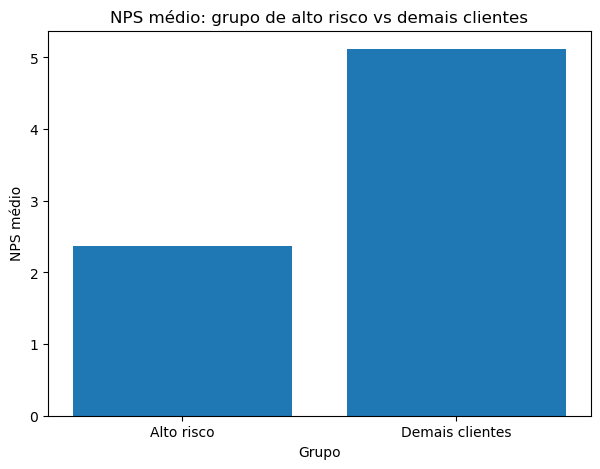

In [35]:

plt.figure(figsize=(7, 5))
plt.bar(resumo_risco["grupo_risco"], resumo_risco["nps_medio"])
plt.title("NPS médio: grupo de alto risco vs demais clientes")
plt.xlabel("Grupo")
plt.ylabel("NPS médio")
plt.show()

### Raciocínio:

Depois de analisar variáveis isoladas, combinamos fatores críticos.

Atraso de 3 ou mais dias já indica uma experiência ruim.
Quatro ou mais reclamações indicam que o problema se repetiu ou não foi bem resolvido.

Quando os dois fatores aparecem juntos, temos um grupo com altíssimo risco de detrator.
Esse grupo deve ser priorizado por logística e atendimento.

In [36]:
# 
ranking_fatores = pd.DataFrame({
    "fator": [
        "Atraso na entrega",
        "Recompra em 30 dias",
        "CSAT interno",
        "Reclamações",
        "Contatos com atendimento",
        "Tempo de resolução"
    ],
    "variavel": [
        "delivery_delay_days",
        "repeat_purchase_30d",
        "csat_internal_score",
        "complaints_count",
        "customer_service_contacts",
        "resolution_time_days"
    ]
})

ranking_fatores = ranking_fatores.merge(
    correlacoes[["variavel", "correlacao_com_nps", "interpretacao"]],
    on="variavel",
    how="left"
)

ranking_fatores["forca_abs"] = ranking_fatores["correlacao_com_nps"].abs()
ranking_fatores = ranking_fatores.sort_values("forca_abs", ascending=False)

display(ranking_fatores)

,fator,variavel,correlacao_com_nps,interpretacao,forca_abs
0,Atraso na entrega,delivery_delay_days,-0.60,Correlação negativa forte,0.60
1,Recompra em 30 dias,repeat_purchase_30d,0.57,Correlação positiva forte,0.57
2,CSAT interno,csat_internal_score,0.56,Correlação positiva forte,0.56
3,Reclamações,complaints_count,-0.50,Correlação negativa moderada,0.50
4,Contatos com atendimento,customer_service_contacts,-0.35,Correlação negativa moderada,0.35
5,Tempo de resolução,resolution_time_days,-0.19,Correlação negativa fraca,0.19


In [37]:

print(f"""
Conclusão executiva:

A base possui {df.shape[0]} registros e {df.shape[1]} colunas.

O NPS médio é {nps_medio:.2f}.
O percentual de detratores é {percentual_detratores:.2f}%.
O percentual de promotores é {percentual_promotores:.2f}%.
O índice NPS estimado é {indice_nps:.2f}.

Os fatores mais associados à queda do NPS são:
1. Atraso na entrega;
2. Reclamações;
3. Contatos com atendimento;
4. Tempo de resolução.

A análise indica que o problema de satisfação parece estar menos ligado ao perfil do cliente
e mais ligado a falhas operacionais na jornada.

Principal ponto de atenção:
clientes com atraso elevado e muitas reclamações formam um grupo de alto risco,
com forte tendência a se tornarem detratores.

Recomendação:
criar alertas preventivos para pedidos com risco de atraso,
priorizar clientes com múltiplas reclamações
e reduzir o esforço do cliente no atendimento.
""")


Conclusão executiva:

A base possui 2500 registros e 27 colunas.

O NPS médio é 4.38.
O percentual de detratores é 84.36%.
O percentual de promotores é 4.40%.
O índice NPS estimado é -79.96.

Os fatores mais associados à queda do NPS são:
1. Atraso na entrega;
2. Reclamações;
3. Contatos com atendimento;
4. Tempo de resolução.

A análise indica que o problema de satisfação parece estar menos ligado ao perfil do cliente
e mais ligado a falhas operacionais na jornada.

Principal ponto de atenção:
clientes com atraso elevado e muitas reclamações formam um grupo de alto risco,
com forte tendência a se tornarem detratores.

Recomendação:
criar alertas preventivos para pedidos com risco de atraso,
priorizar clientes com múltiplas reclamações
e reduzir o esforço do cliente no atendimento.



In [61]:
# 1. Variáveis demográficas/geográficas
resumo_regiao.to_csv("..\\reports\\01_resumo_regiao.csv", index=False)
resumo_faixa_etaria.to_csv("..\\reports\\02_resumo_etaria.csv", index=False)


# 2 Variáveis operacionais (o que acontece durante o serviço)
resumo_atraso.to_csv("..\\reports\\03_resumo_atraso.csv", index=False)
resumo_contatos.to_csv("..\\reports\\04_resumo_contatos.csv", index=False)
resumo_reclamacoes.to_csv("..\\reports\\05_resumo_reclamacoes.csv", index=False)
resumo_resolucao.to_csv("..\\reports\\06_resumo_resolucao.csv", index=False)

# 3. Variáveis de resultado
resumo_csat.to_csv("..\\reports\\07_resumo_csat.csv", index=False)
ranking_fatores.to_csv("..\\reports\\08_ranking_fatores_nps.csv", index=False)

# 4. Dataframe_processado
df.to_csv("..\\data\\processed\\desafio_nps_fase_1_processado.csv", index=False)

print("Arquivos salvos com sucesso.")

Arquivos salvos com sucesso.
